# Principle Component Analysis with an example

### Loading dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('E:/Dataset/digit_recognition.csv')

In [5]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
9292,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39473,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15216,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7304,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16209,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Visuaalizing dataset

In [6]:
import matplotlib.pyplot as plt

In [7]:
df.sample(2, random_state=2)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
38732,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3686,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


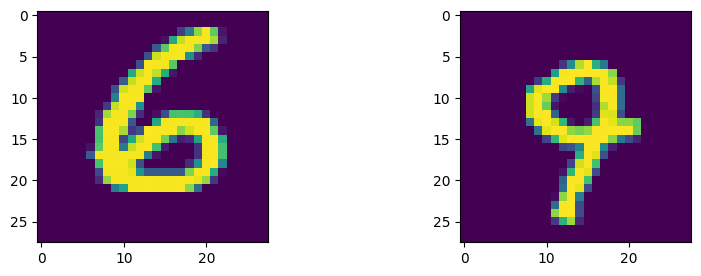

In [13]:
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.imshow(df.iloc[38732, 1:].values.reshape(28,28))

plt.subplot(122)
plt.imshow(df.iloc[3686, 1:].values.reshape(28,28))

## First properties of PCA(Reduce dimension)

### Splitting dataset

In [16]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [17]:
x.sample()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
12621,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
from sklearn.model_selection import train_test_split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=3)

In [19]:
x_train.sample(2)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
15586,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35844,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Training ML-model before using PCA

In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [42]:
knn1 = KNeighborsClassifier()
knn1.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [47]:
import time
start_time = time.time()

y_pred1 = knn1.predict(x_test)

print(f'Time taken: {time.time() - start_time}')

Time taken: 17.931591987609863


In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred1)

0.9648809523809524

### Training ML-model after using PCA

In [14]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [25]:
x_train_scaled.std()

np.float64(0.9482798605251253)

In [26]:
from sklearn.decomposition import PCA

In [32]:
pca = PCA(n_components=100)

In [33]:
x_train_trf = pca.fit_transform(x_train_scaled)
x_test_trf = pca.transform(x_test_scaled)

In [34]:
x_train_trf.shape

(33600, 100)

In [36]:
knn = KNeighborsClassifier()

In [37]:
knn.fit(x_train_trf, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [38]:
y_pred = knn.predict(x_test_trf)

In [40]:
accuracy_score(y_test, y_pred)

0.9525

### Loop for taking one by one n_components

In [49]:
import time
start_time = time.time()

for i in range(1, 16):
    pca = PCA(n_components=i)

    x_train_trf = pca.fit_transform(x_train_scaled)
    x_test_trf = pca.transform(x_test_scaled)

    knn.fit(x_train_trf, y_train)
    y_pred2 = knn.predict(x_test_trf)

    print(f'Accuracy with n_components={i}: {accuracy_score(y_pred2, y_test)}')

print(f'Time taken: {time.time() - start_time}')

Accuracy with n_components=1: 0.24773809523809523
Accuracy with n_components=2: 0.32404761904761903
Accuracy with n_components=3: 0.5054761904761905
Accuracy with n_components=4: 0.664047619047619
Accuracy with n_components=5: 0.7283333333333334
Accuracy with n_components=6: 0.8216666666666667
Accuracy with n_components=7: 0.8332142857142857
Accuracy with n_components=8: 0.8682142857142857
Accuracy with n_components=9: 0.8829761904761905
Accuracy with n_components=10: 0.9044047619047619
Accuracy with n_components=11: 0.9145238095238095
Accuracy with n_components=12: 0.9158333333333334
Accuracy with n_components=13: 0.9202380952380952
Accuracy with n_components=14: 0.9305952380952381
Accuracy with n_components=15: 0.9329761904761905
Time taken: 36.74431800842285
